# BioJEPA v0.7 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_7 import BioJepa, BioJepaConfig
from dataloader_v0_7 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v0_7 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v0_7 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/v0_7').expanduser()
ref_root = Path('~/data/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cuda


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer= 6,
    heads= 4,
    embed_dim= 256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=50,
    std_coeff=25,
    cov_coeff=1,
    pert_latent_dim=128,
    pert_mode_dim=64,
)

# Encoder training: WSD schedule with context L2 and EMA annealing in phase 2
encoder_cfg = EncoderTrainingConfig(
    epochs=50, lr=5e-5, batch_size=64, phase2_start_pct=0.8, context_coeff=2.0, context_ramp_pct=0.2, ema_final_momentum=1.0,
)

# Composer training: InfoNCE loss with modality-balanced sampling (v0.7 HPO v8 winner)
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=3.6e-4, batch_size=64, weight_decay=0.003, temperature=0.00126, chemical_fraction=0.1,
)    

# AC training: mask annealing in final 20%
ac_cfg = ACTrainingConfig(
    epochs=20, predictor_lr=1e-4, batch_size=32, mask_anneal_pct=0.2, mask_anneal_floor=0.0, 
    beta_nll_target=0.2, beta_nll_anneal_pct=0.4,composer_lr_mult=0.01
)

decoder_cfg = DecoderConfig(epochs=10, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
#model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,522
ACpredictor: 9,987,072
PerturbationComposer: 444,224


### Load pretraining model from checkpoint (for resuming)

In [5]:
model = maybe_compile(model, USE_COMPILE)
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_7_ac_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path, map_location=device)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

In [ ]:
# decompress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
# decompress_npz(data_cfg.data_root / 'predictor_t') 

## Encoder Training

In [ ]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device )
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device)

In [ ]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Encoder Training Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

In [ ]:
# compress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 2: Composer Training

In [7]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
  modality balancing: target chemical_fraction=10%
  adjusted total_samples=11829 (from 1 shards)
found 1 shards for split val


In [ ]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, target_bank, composer_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Composer Training Evals

In [8]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

Using cuda
Loaded 10791 v0.7 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 128])
Encoded chemical sequences: torch.Size([188, 128])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 128])
seq_to_target_retrieval: dna_mrr=0.2539
cross_modality_target_consistency: Within=0.7026, Between=0.6380, Ratio=1.10x
seq_target_gap_analysis: dna_gap=0.79
paired_alignment_quality: dna_sim=0.8191
mode_sensitivity: Classification_acc=0.7429 (5.2x chance)
mode_semantic_consistency: semantic_gap=-0.0329, cross_mode_mrr=0.0822
fusion_quality: Fused_var=0.5265, Seq_var=0.4129, Target_var=0.0658
missing_data_robustness: Fused_MRR=0.8228, Seq_only=0.2497, Target_only=0.9925
found 135 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|██████| 500/500 [00:03<00:00, 126.33it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0825, target_only=0.1715, fused=0.1894
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
action_vector_pathways DNA: ratio=1.0027060843411473
Saved report to /home/ubuntu/data/v0_7/eval_results/composer_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.25393486142666283,
    'median_rank': 5.0,
    'mean_rank': 90.21636876763876,
    'n_queries': 10630,
    'n_targets': 9975,
    'recall_at_k': {'1': 0.04656632173095014,
     '5': 0.5373471307619944,
     '10': 0.9036688617121355,
     '20': 0.9793038570084666,
     '50': 0.9816556914393226}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 921,
   'n_within_pairs': 1408,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.702555239200592,
   'between_target_sim': 0.6380362896621228,
   'consistency_ratio': 1.1011211283493543}},
 'seq_target_gap_analysis': {'target_variance': 8.133279800415039,
  'n_targets': 9975,
  'dna': {'seq_variance': 55.0455207824707,
   'centroid_distance': 2.5343034267425537,
   'mean_within_seq': 10.459054089406864,
   'mean_seq_to_target': 8.304259300231934,
   'gap_ratio': 0.7939780432575304,
   'n_sequences': 11643}},
 'pair

In [9]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): OptimizedModule(
    (_orig_mod): CellStateEncoder(
      (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_projection): GaussianFourierProjection()
      (film_generator): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=512, bias=True)
      )
      (total_count_proj): Linear(in_features=1, out_features=256, bias=True)
      (blocks): ModuleList(
        (0-5): 6 x CellStateBlock(
          (ln_1): RMSNorm()
          (attn): BioLinearAttention(
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (c_proj): Linear(in_features=256, out_features=256, bias=True)

## Stage 3: AC Training

In [10]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, 
                               data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
AC training: 3857920 samples, 120560 steps/epoch, 2411200 total steps
Mask annealing: starts at step 1928960 (0.766 -> 0.000)
Beta-NLL: target=0.20, anneal steps=964480
Step 0 | val loss: 207.8901
Step 0 | Loss: 211.67989 | LR: 4.00e-06 | Beta: 0.000
Step 1000 | Loss: 76.55814 | LR: 4.02e-06 | Beta: 0.000
Step 2000 | Loss: 70.86101 | LR: 4.07e-06 | Beta: 0.000
Step 3000 | Loss: 70.51129 | LR: 4.15e-06 | Beta: 0.001
Step 4000 | Loss: 70.48652 | LR: 4.26e-06 | Beta: 0.001
Step 5000 | val loss: 77.2669
Step 5000 | Loss: 67.24976 | LR: 4.41e-06 | Beta: 0.001
Step 6000 | Loss: 68.92104 | LR: 4.59e-06 | Beta: 0.001
Step 7000 | Loss: 68.60202 | LR: 4.80e-06 | Beta: 0.001
Step 8000 | Loss: 69.05815 | LR: 5.04e-0

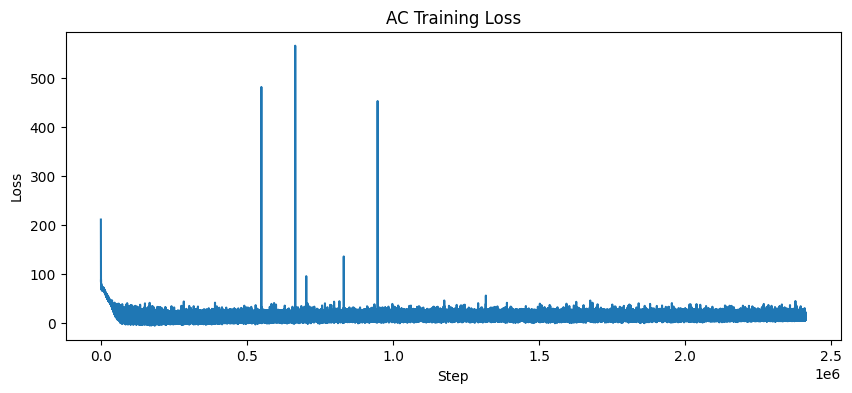

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [12]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [ ]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, 
                                                model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, 
                                                use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
Decoder training: 3857920 samples, 120560 steps/epoch, 1205600 total steps
Decoder Step 0 | val loss: 0.8829
Decoder Step 0 | Loss: 1.38630
Decoder Step 1000 | Loss: 0.39715
Decoder Step 2000 | Loss: 0.69174
Decoder Step 3000 | Loss: 0.15142
Decoder Step 4000 | Loss: 0.15583
Decoder Step 5000 | val loss: 0.1730
Decoder Step 5000 | Loss: 0.18822
Decoder Step 6000 | Loss: 0.16339
Decoder Step 7000 | Loss: 0.37954
Decoder Step 8000 | Loss: 0.16085
Decoder Step 9000 | Loss: 0.15671
Decoder Step 10000 | val loss: 0.1816
Decoder Step 10000 | Loss: 0.36966
Decoder Step 11000 | Loss: 0.19765
Decoder Step 12000 | Loss: 0.14781
Decoder Step 13000 | Loss: 0.35230
Decoder Step 14000 | Loss: 0.34865
Decoder Step 1500

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

In [ ]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Encoder training final loss: {pt_results["final_loss"]:.5f}')
print(f'Composer training final loss: {align_results["final_loss"]:.5f}')
print(f'AC training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')